In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/preprocessing_log.csv
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_00299.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_01332.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_00807.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_01838.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_01236.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_00037.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_01509.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/patches/A8/TCGA-A8-A07L/TCGA-A8-A07L_00179.jpg
/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2/pa

In [1]:
# ============================================================
# SECTION 1A : IMPORTS
# ============================================================

import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)
# ============================================================
# SECTION 1B : DATASET PATHS
# ============================================================

from pathlib import Path

ANISHA = Path("/kaggle/input/datasets/anishapanja")
COAUTHOR = Path("/kaggle/input/datasets/hritishachoudhury")

MANIFEST_DIR = ANISHA / "bc-xai-final-manifest"

PATCH_CSV = MANIFEST_DIR / "patches_with_split_final.csv"
PATIENT_CSV = MANIFEST_DIR / "patient_summary.csv"

DATASET_ROOTS = {

    "A2": ANISHA / "bc-xai-a2-2000-partial",

    "E2": ANISHA / "bc-xai-e2-2000",

    "A8_1": ANISHA / "bc-xai-a8-patches-batch1",
    "A8_2": ANISHA / "bc-xai-a8-patches-batch2",
    "A8_3": ANISHA / "bc-xai-a8-patches-batch3",
    "A8_4": ANISHA / "bc-xai-a8-patches-batch4",
    "A8_5": ANISHA / "bc-xai-a8-patches-batch5",

    "C8_1": ANISHA / "bc-xai-c8-patches-batch1",
    "C8_2": ANISHA / "bc-xai-c8-patches-batch2",
    "C8_3": ANISHA / "bc-xai-c8-patches-batch3",
    "C8_4": ANISHA / "bc-xai-c8-patches-batch4",

    "D8": COAUTHOR / "bc-xai-d8-patches",

    "BH": COAUTHOR / "bc-xai-bh-patches",
}
# ============================================================
# SECTION 1C : VERIFY + LOAD CSV
# ============================================================

import pandas as pd

patch_df = pd.read_csv(PATCH_CSV)
patient_df = pd.read_csv(PATIENT_CSV)

print("Patch shape :", patch_df.shape)
print("Patient shape :", patient_df.shape)

display(patch_df.head())
display(patient_df.head())
print("\nLoaded Successfully!\n")




Patch shape : (786911, 8)
Patient shape : (343, 6)


,patient_id,site,subtype,subtype_clean,dataset,relative_path,patch_name,split
0,TCGA-A2-A04N,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04N-01Z-0...,TCGA-A2-A04N-01Z-00-DX1.9E9B7DB0-1CF1-4631-829...,test
1,TCGA-A2-A04N,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04N-01Z-0...,TCGA-A2-A04N-01Z-00-DX1.9E9B7DB0-1CF1-4631-829...,test
2,TCGA-A2-A04N,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04N-01Z-0...,TCGA-A2-A04N-01Z-00-DX1.9E9B7DB0-1CF1-4631-829...,test
3,TCGA-A2-A04N,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04N-01Z-0...,TCGA-A2-A04N-01Z-00-DX1.9E9B7DB0-1CF1-4631-829...,test
4,TCGA-A2-A04N,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04N-01Z-0...,TCGA-A2-A04N-01Z-00-DX1.9E9B7DB0-1CF1-4631-829...,test


,patient_id,site,subtype,subtype_clean,patches,split
0,TCGA-A2-A0YJ,A2,BRCA_Basal,Basal,2719,train
1,TCGA-A2-A4S1,A2,BRCA_Basal,Basal,1326,train
2,TCGA-E2-A15P,E2,BRCA_LumA,LumA,1616,train
3,TCGA-C8-A1HK,C8,BRCA_Her2,Her2,2000,train
4,TCGA-E2-A1B5,E2,BRCA_LumA,LumA,1999,train



Loaded Successfully!



In [2]:
# ============================================================
# SECTION 2A : SAMPLE TRAINING PATCHES
# ============================================================

SITES = ["A2", "A8", "BH", "C8", "D8", "E2"]

SAMPLES_PER_SITE = 200
SEED = 42

train_df = patch_df[patch_df["split"] == "train"].copy()

sampled = []

for site in SITES:

    site_df = train_df[train_df["site"] == site]

    n = min(SAMPLES_PER_SITE, len(site_df))

    sampled.append(
        site_df.sample(
            n=n,
            random_state=SEED,
            replace=False
        )
    )

sample_df = (
    pd.concat(sampled)
      .reset_index(drop=True)
)

print(sample_df.shape)

display(sample_df.head())
# ============================================================
# CHECK SAMPLE DISTRIBUTION
# ============================================================

print(sample_df["site"].value_counts())

print()

print(sample_df.groupby(["site","subtype_clean"]).size())
# ============================================================
# SECTION 2B : BUILD FULL IMAGE PATHS
# ============================================================

from pathlib import Path

DATASET_MAP = {
    "bc-xai-a2-2000-partial": ANISHA / "bc-xai-a2-2000-partial",
    "bc-xai-e2-2000": ANISHA / "bc-xai-e2-2000",

    "bc-xai-a8-patches-batch1": ANISHA / "bc-xai-a8-patches-batch1",
    "bc-xai-a8-patches-batch2": ANISHA / "bc-xai-a8-patches-batch2",
    "bc-xai-a8-patches-batch3": ANISHA / "bc-xai-a8-patches-batch3",
    "bc-xai-a8-patches-batch4": ANISHA / "bc-xai-a8-patches-batch4",
    "bc-xai-a8-patches-batch5": ANISHA / "bc-xai-a8-patches-batch5",

    "bc-xai-c8-patches-batch1": ANISHA / "bc-xai-c8-patches-batch1",
    "bc-xai-c8-patches-batch2": ANISHA / "bc-xai-c8-patches-batch2",
    "bc-xai-c8-patches-batch3": ANISHA / "bc-xai-c8-patches-batch3",
    "bc-xai-c8-patches-batch4": ANISHA / "bc-xai-c8-patches-batch4",

    "bc-xai-d8-patches": COAUTHOR / "bc-xai-d8-patches",
    "bc-xai-bh-patches": COAUTHOR / "bc-xai-bh-patches",
}

def build_image_path(row):
    root = DATASET_MAP[row["dataset"]]
    return root / row["relative_path"]

sample_df["image_path"] = sample_df.apply(build_image_path, axis=1)
# ============================================================
# VERIFY IMAGE PATHS
# ============================================================

sample_df["exists"] = sample_df["image_path"].apply(Path.exists)

print(sample_df["exists"].value_counts())

display(
    sample_df[
        ["dataset",
         "site",
         "relative_path",
         "image_path",
         "exists"]
    ].head()
)
# ============================================================
# SECTION 3 : DISPLAY PATCH GRID
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

def show_patch_grid(df, site, start=0, grid_size=10):

    site_df = df[df.site == site].reset_index(drop=True)

    subset = site_df.iloc[start:start + grid_size * grid_size]

    fig, axes = plt.subplots(
        grid_size,
        grid_size,
        figsize=(20,20)
    )

    for i, (ax, (_, row)) in enumerate(zip(axes.flat, subset.iterrows())):

        img = Image.open(row.image_path)

        ax.imshow(img)

        ax.set_title(str(i+1), fontsize=8)

        ax.axis("off")

    plt.suptitle(
        f"{site} | Patches {start+1}-{start+100}",
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

    return subset.reset_index(drop=True)

(1200, 8)


,patient_id,site,subtype,subtype_clean,dataset,relative_path,patch_name,split
0,TCGA-A2-A04V,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04V-01Z-0...,TCGA-A2-A04V-01Z-00-DX1.EB430DDB-8FE9-4302-882...,train
1,TCGA-A2-A0YC,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A0YC-01Z-0...,TCGA-A2-A0YC-01Z-00-DX1.F01F2268-17D8-45FD-891...,train
2,TCGA-A2-A3XT,A2,BRCA_Basal,Basal,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A3XT-01Z-0...,TCGA-A2-A3XT-01Z-00-DX1.336D6C78-576A-481B-8C8...,train
3,TCGA-A2-A0CP,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A0CP-01Z-0...,TCGA-A2-A0CP-01Z-00-DX1.ECFD263C-BB17-4ADA-8F2...,train
4,TCGA-A2-A0SY,A2,BRCA_LumA,LumA,bc-xai-a2-2000-partial,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A0SY-01Z-0...,TCGA-A2-A0SY-01Z-00-DX1.279A5479-E183-4F79-AF4...,train


site
A2    200
A8    200
BH    200
C8    200
D8    200
E2    200
Name: count, dtype: int64

site  subtype_clean
A2    Basal             39
      Her2              11
      LumA             104
      LumB              46
A8    Basal              8
      Her2              29
      LumA              88
      LumB              75
BH    Her2              53
      LumB             147
C8    Basal             28
      Her2              51
      LumA              49
      LumB              72
D8    Her2              44
      LumB             156
E2    Basal             41
      Her2              15
      LumA             118
      LumB              26
dtype: int64
exists
True    1200
Name: count, dtype: int64


,dataset,site,relative_path,image_path,exists
0,bc-xai-a2-2000-partial,A2,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A04V-01Z-0...,/kaggle/input/datasets/anishapanja/bc-xai-a2-2...,True
1,bc-xai-a2-2000-partial,A2,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A0YC-01Z-0...,/kaggle/input/datasets/anishapanja/bc-xai-a2-2...,True
2,bc-xai-a2-2000-partial,A2,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A3XT-01Z-0...,/kaggle/input/datasets/anishapanja/bc-xai-a2-2...,True
3,bc-xai-a2-2000-partial,A2,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A0CP-01Z-0...,/kaggle/input/datasets/anishapanja/bc-xai-a2-2...,True
4,bc-xai-a2-2000-partial,A2,A2_full/BLOCKS_NORM_MACENKO/TCGA-A2-A0SY-01Z-0...,/kaggle/input/datasets/anishapanja/bc-xai-a2-2...,True


In [3]:
# ============================================================
# MASTER DATASET FOR AUTOMATIC QUALITY ANALYSIS
# ============================================================

current_grid = sample_df.copy()

print(f"Total sampled patches: {len(current_grid)}")
print(current_grid["site"].value_counts())

Total sampled patches: 1200
site
A2    200
A8    200
BH    200
C8    200
D8    200
E2    200
Name: count, dtype: int64


In [4]:
# ============================================================
# SECTION 4 : AUTOMATIC PATCH QUALITY ANALYSIS
# ============================================================

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Metric Functions
# ------------------------------------------------------------

def tissue_percentage(img, od_threshold=0.15):
    """
    Estimate tissue coverage using Optical Density (OD).

    OD-based masking is more robust than grayscale thresholding
    for H&E-stained histopathology images.

    Returns:
        tissue percentage
    """

    img = img.astype(np.float32) + 1.0

    # Optical Density
    od = -np.log(img / 255.0)

    # Mean OD across RGB channels
    od_mean = od.mean(axis=2)

    tissue_mask = od_mean > od_threshold

    tissue = tissue_mask.sum()

    total = tissue_mask.size

    return 100 * tissue / total

def background_percentage(img):

    return 100 - tissue_percentage(img)


def blur_score(img):
    """
    Variance of Laplacian.
    Higher = sharper image.
    """

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()

def brightness(img):

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    return hsv[:, :, 2].mean()


def rgb_statistics(img):

    return (
        img[:, :, 0].mean(),
        img[:, :, 1].mean(),
        img[:, :, 2].mean()
    )


# ------------------------------------------------------------
# Compute Metrics
# ------------------------------------------------------------

quality_results = []

for _, row in tqdm(current_grid.iterrows(), total=len(current_grid)):

    img = cv2.imread(row["image_path"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tissue = tissue_percentage(img)

    background = 100 - tissue

    sharpness = blur_score(img)

    bright = brightness(img)

    r, g, b = rgb_statistics(img)

    quality_results.append({

        "patch_name": row["patch_name"],

        "site": row["site"],

        "subtype": row["subtype_clean"],

        "tissue_percent": tissue,

        "background_percent": background,

        "sharpness_score": sharpness,

        "brightness": bright,

        "mean_R": r,

        "mean_G": g,

        "mean_B": b

    })

quality_df = pd.DataFrame(quality_results)

print("Total patches analysed :", len(quality_df))

display(quality_df.head())
# ============================================================
# SECTION 5 : QUALITY SUMMARY
# ============================================================

summary = (
    quality_df
    .groupby("site")
    .agg(
        n_patches=("patch_name", "count"),
        tissue_mean=("tissue_percent", "mean"),
        tissue_std=("tissue_percent", "std"),
        background_mean=("background_percent", "mean"),
        sharpness_mean=("sharpness_score", "mean"),
        brightness_mean=("brightness", "mean"),
    )
    .round(2)
)

display(summary)



  0%|          | 0/1200 [00:00<?, ?it/s]

Total patches analysed : 1200


,patch_name,site,subtype,tissue_percent,background_percent,sharpness_score,brightness,mean_R,mean_G,mean_B
0,TCGA-A2-A04V-01Z-00-DX1.EB430DDB-8FE9-4302-882...,A2,LumA,88.281250,11.718750,4852.842432,182.974548,182.627563,103.128067,144.426407
1,TCGA-A2-A0YC-01Z-00-DX1.F01F2268-17D8-45FD-891...,A2,LumA,90.425110,9.574890,7885.608199,182.140503,181.035660,108.256607,149.833405
2,TCGA-A2-A3XT-01Z-00-DX1.336D6C78-576A-481B-8C8...,A2,Basal,97.764587,2.235413,6054.985676,189.147614,188.893143,99.427689,142.553116
3,TCGA-A2-A0CP-01Z-00-DX1.ECFD263C-BB17-4ADA-8F2...,A2,LumA,68.844604,31.155396,5079.840815,168.471878,168.214340,115.958664,149.690460
4,TCGA-A2-A0SY-01Z-00-DX1.279A5479-E183-4F79-AF4...,A2,LumA,90.701294,9.298706,25257.023978,176.978821,176.920334,103.495010,144.982254


,n_patches,tissue_mean,tissue_std,background_mean,sharpness_mean,brightness_mean
site,,,,,,
A2,200,83.33,14.33,16.67,9287.13,186.89
A8,200,43.90,23.16,56.10,47901.61,188.58
BH,200,14.10,9.16,85.90,488.18,245.68
C8,200,58.95,25.63,41.05,35565.17,163.47
D8,200,12.37,5.11,87.63,1155.32,244.92
E2,200,78.52,14.92,21.48,14133.43,191.17


A2


KeyError: 'blur_score'

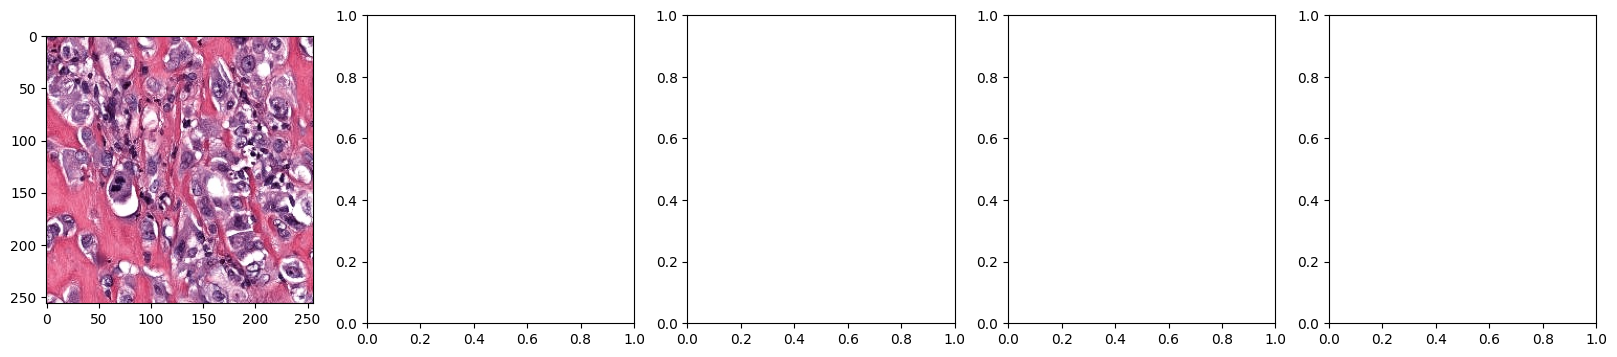

In [7]:
# ============================================================
# SECTION 6 : VISUAL VALIDATION OF QUALITY METRICS
# ============================================================

import matplotlib.pyplot as plt
import cv2
import random

random.seed(42)

sites = sorted(quality_df["site"].unique())

PATCHES_PER_SITE = 5

for site in sites:

    print("=" * 80)
    print(f"{site}")
    print("=" * 80)

    site_df = quality_df[quality_df["site"] == site].sample(
        PATCHES_PER_SITE,
        random_state=42
    )

    fig, axes = plt.subplots(1, PATCHES_PER_SITE, figsize=(20,4))

    for ax, (_, row) in zip(axes, site_df.iterrows()):

        img_path = current_grid.loc[
            current_grid["patch_name"] == row["patch_name"],
            "image_path"
        ].values[0]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)

        ax.set_title(
            f"Tissue : {row['tissue_percent']:.1f}%\n"
            f"BG : {row['background_percent']:.1f}%\n"
            f"Blur : {row['blur_score']:.0f}",
            fontsize=8
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

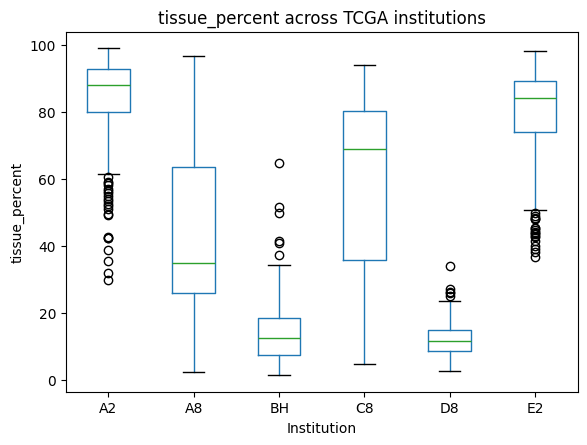

<Figure size 1000x600 with 0 Axes>

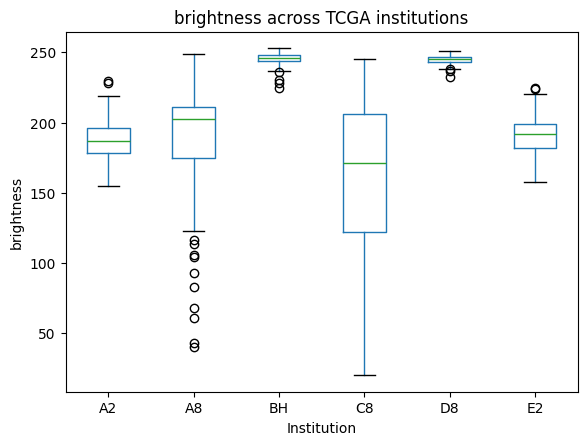

<Figure size 1000x600 with 0 Axes>

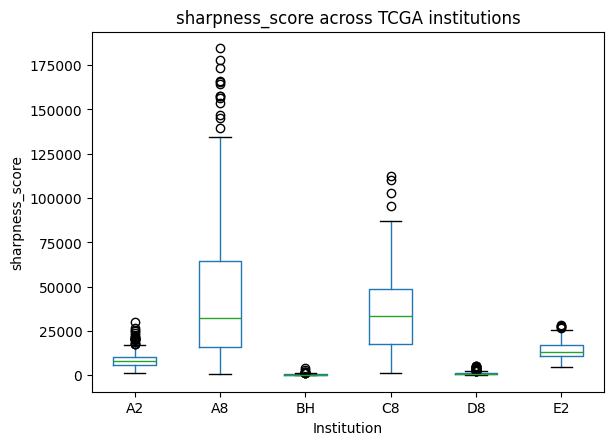

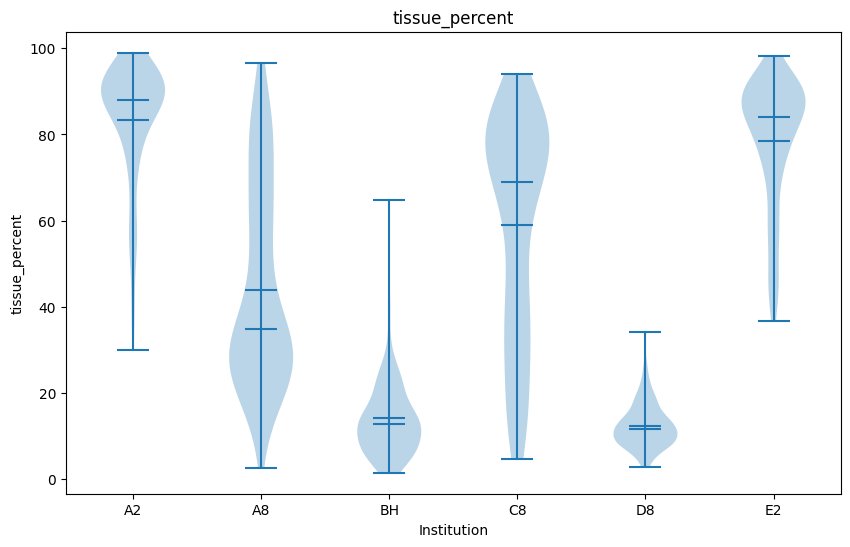

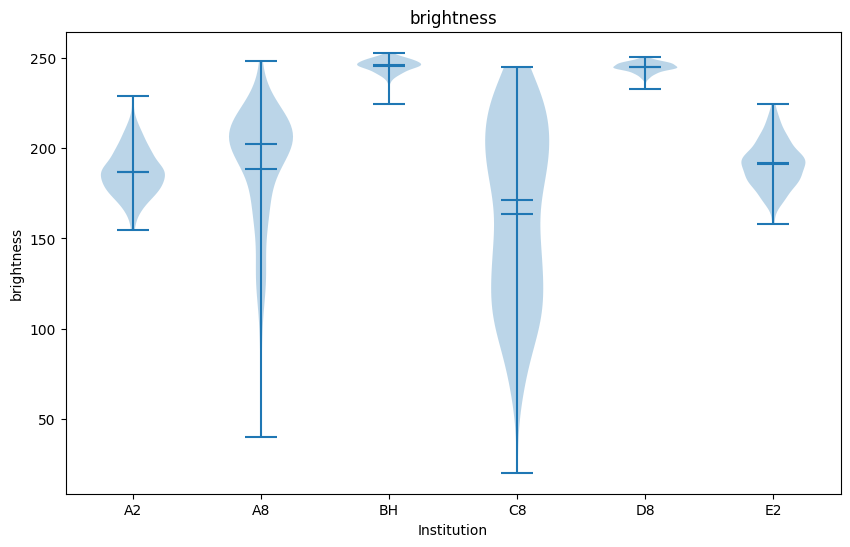

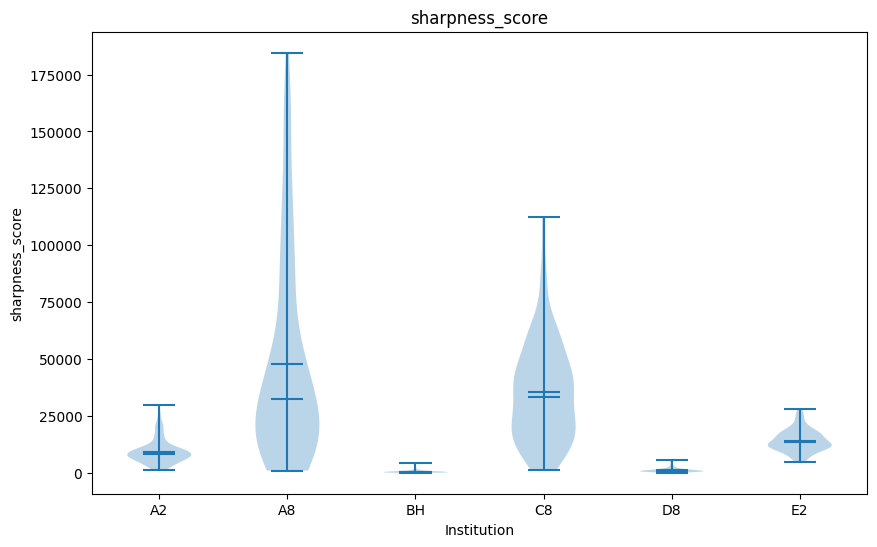

In [8]:
# ============================================================
# SECTION 7.1 : INSTITUTION-WISE DISTRIBUTION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

metrics = [
    "tissue_percent",
    "brightness",
    "sharpness_score"
]

for metric in metrics:

    plt.figure(figsize=(10,6))

    quality_df.boxplot(
        column=metric,
        by="site",
        grid=False
    )

    plt.title(f"{metric} across TCGA institutions")
    plt.suptitle("")
    plt.xlabel("Institution")
    plt.ylabel(metric)

    plt.show()
    # ============================================================
# SECTION 7.2 : VIOLIN PLOTS
# ============================================================

import matplotlib.pyplot as plt

metrics = [
    "tissue_percent",
    "brightness",
    "sharpness_score"
]

for metric in metrics:

    plt.figure(figsize=(10,6))

    data = [
        quality_df.loc[
            quality_df.site == site,
            metric
        ]
        for site in sorted(quality_df.site.unique())
    ]

    plt.violinplot(
        data,
        showmeans=True,
        showmedians=True
    )

    plt.xticks(
        range(1, len(sorted(quality_df.site.unique()))+1),
        sorted(quality_df.site.unique())
    )

    plt.title(metric)

    plt.xlabel("Institution")

    plt.ylabel(metric)

    plt.show()

In [9]:
from scipy.stats import shapiro

metrics = [
    "tissue_percent",
    "brightness",
    "sharpness_score"
]

for metric in metrics:

    print("\n" + "=" * 60)
    print(metric)
    print("=" * 60)

    for site in sorted(quality_df.site.unique()):

        values = quality_df.loc[
            quality_df.site == site,
            metric
        ]

        stat, p = shapiro(values)

        print(f"{site:>2}   W={stat:.4f}   p={p:.5f}")


tissue_percent
A2   W=0.7956   p=0.00000
A8   W=0.9180   p=0.00000
BH   W=0.8653   p=0.00000
C8   W=0.8969   p=0.00000
D8   W=0.9543   p=0.00000
E2   W=0.8422   p=0.00000

brightness
A2   W=0.9898   p=0.16987
A8   W=0.8311   p=0.00000
BH   W=0.9065   p=0.00000
C8   W=0.9595   p=0.00002
D8   W=0.9679   p=0.00016
E2   W=0.9936   p=0.53848

sharpness_score
A2   W=0.8921   p=0.00000
A8   W=0.8470   p=0.00000
BH   W=0.7309   p=0.00000
C8   W=0.9528   p=0.00000
D8   W=0.7807   p=0.00000
E2   W=0.9707   p=0.00034


In [10]:
from scipy.stats import kruskal

metrics = [
    "tissue_percent",
    "brightness",
    "sharpness_score"
]

for metric in metrics:

    groups = [
        quality_df.loc[quality_df.site == site, metric]
        for site in sorted(quality_df.site.unique())
    ]

    H, p = kruskal(*groups)

    print("=" * 60)
    print(metric)
    print(f"H statistic : {H:.4f}")
    print(f"p-value     : {p:.10f}")

tissue_percent
H statistic : 867.7219
p-value     : 0.0000000000
brightness
H statistic : 813.8793
p-value     : 0.0000000000
sharpness_score
H statistic : 933.4542
p-value     : 0.0000000000


In [11]:
!pip install -q scikit-posthocs


In [12]:
import scikit_posthocs as sp

metrics = [
    "tissue_percent",
    "brightness",
    "sharpness_score"
]

for metric in metrics:

    print("\n")
    print("="*70)
    print(metric)
    print("="*70)

    dunn = sp.posthoc_dunn(
        quality_df,
        val_col=metric,
        group_col="site",
        p_adjust="holm"
    )

    display(dunn)



tissue_percent


,A2,A8,BH,C8,D8,E2
A2,1.000000e+00,1.666238e-28,1.147193e-99,8.743126e-16,9.529452e-106,6.694637e-02
A8,1.666238e-28,1.000000e+00,6.728705e-23,7.298850e-03,8.653935e-26,3.632209e-19
BH,1.147193e-99,6.728705e-23,1.000000e+00,4.451377e-38,5.164575e-01,5.498459e-81
C8,8.743126e-16,7.298850e-03,4.451377e-38,1.000000e+00,7.813558e-42,3.940295e-09
D8,9.529452e-106,8.653935e-26,5.164575e-01,7.813558e-42,1.000000e+00,1.829076e-86
E2,6.694637e-02,3.632209e-19,5.498459e-81,3.940295e-09,1.829076e-86,1.000000e+00




brightness


,A2,A8,BH,C8,D8,E2
A2,1.000000e+00,1.324912e-02,1.348691e-75,4.956325e-01,2.644170e-67,4.956325e-01
A8,1.324912e-02,1.000000e+00,4.509629e-53,5.194303e-05,3.343044e-46,4.956325e-01
BH,1.348691e-75,4.509629e-53,1.000000e+00,1.930727e-87,4.956325e-01,7.001427e-64
C8,4.956325e-01,5.194303e-05,1.930727e-87,1.000000e+00,1.721842e-78,1.626906e-02
D8,2.644170e-67,3.343044e-46,4.956325e-01,1.721842e-78,1.000000e+00,2.700751e-56
E2,4.956325e-01,4.956325e-01,7.001427e-64,1.626906e-02,2.700751e-56,1.000000e+00




sharpness_score


,A2,A8,BH,C8,D8,E2
A2,1.000000e+00,2.213057e-21,6.501575e-37,1.652136e-22,1.369116e-20,5.989693e-05
A8,2.213057e-21,1.000000e+00,1.546286e-111,7.835434e-01,5.764238e-81,2.255648e-07
BH,6.501575e-37,1.546286e-111,1.000000e+00,3.208675e-114,1.491421e-03,9.961261e-65
C8,1.652136e-22,7.835434e-01,3.208675e-114,1.000000e+00,3.047780e-83,5.831287e-08
D8,1.369116e-20,5.764238e-81,1.491421e-03,3.047780e-83,1.000000e+00,4.650889e-42
E2,5.989693e-05,2.255648e-07,9.961261e-65,5.831287e-08,4.650889e-42,1.000000e+00


In [13]:
import os

dataset_path = "/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/__huggingface_repos__.json
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/config.json
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/classification_report.csv
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/accuracy_curve.png
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/f1_curve.png
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/confusion_matrix.png
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/roc_curves.png
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/experiment_summary.txt
/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/experimen

In [14]:
import pandas as pd

base = "/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3"

summary = pd.read_csv(f"{base}/experiment_summary.csv")
report = pd.read_csv(f"{base}/classification_report.csv")
history = pd.read_csv(f"{base}/history.csv")
auc = pd.read_csv(f"{base}/auc_scores.csv")
preds = pd.read_csv(f"{base}/test_predictions_with_probabilities.csv")

print("Experiment Summary")
display(summary)

print("Classification Report")
display(report)

print("History")
display(history.head())

print("AUC Scores")
display(auc)

print("Predictions")
display(preds.head())

Experiment Summary


,Model,Image_Size,Batch_Size,Epochs_Trained,Best_Epoch,Best_Validation_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Macro_AUC,Micro_AUC,Training_Time_Seconds,Training_Time_Minutes,Training_Time_Hours
0,resnet50,224,64,19,14,0.482259,0.523013,0.479942,0.486783,0.471604,0.75496,0.784109,32413.206539,540.220109,9.003668


Classification Report


,Unnamed: 0,precision,recall,f1-score,support
0,Basal,0.431667,0.524993,0.473778,13964.000000
1,Her2,0.272114,0.263145,0.267555,16261.000000
2,LumA,0.537180,0.728898,0.618523,41844.000000
3,LumB,0.678807,0.430095,0.526560,47536.000000
4,accuracy,0.523013,0.523013,0.523013,0.523013
5,macro avg,0.479942,0.486783,0.471604,119605.000000
6,weighted avg,0.545113,0.523013,0.517358,119605.000000


History


,train_loss,val_loss,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,learning_rate,epoch_time
0,0.771116,1.308990,0.647321,0.485867,0.621103,0.451891,0.661285,0.465017,0.624688,0.451274,0.000100,5712.025092
1,0.569056,1.427243,0.742076,0.501079,0.714074,0.452369,0.757487,0.473665,0.726803,0.454588,0.000100,5481.216125
2,0.490592,1.447193,0.779506,0.496665,0.752489,0.464402,0.792553,0.482154,0.766197,0.467800,0.000099,5683.980490
3,0.439814,1.492022,0.802702,0.506821,0.777622,0.456831,0.815472,0.467682,0.791388,0.460454,0.000098,5769.816084
4,0.402658,1.625308,0.819635,0.503736,0.795695,0.449910,0.831807,0.471247,0.809338,0.456744,0.000096,5745.514726


AUC Scores


,Class,AUC
0,Basal,0.832822
1,Her2,0.689164
2,LumA,0.779762
3,LumB,0.718093
4,Micro Average,0.784109
5,Macro Average,0.754960


Predictions


,patient_id,site,true_subtype,true_label,predicted_label,predicted_subtype,Probability_Basal,Probability_Her2,Probability_LumA,Probability_LumB,Confidence,Correct
0,TCGA-A2-A04N,A2,LumA,2,2,LumA,0.09753,0.028810,0.69600,0.178000,0.6960,True
1,TCGA-A2-A04N,A2,LumA,2,0,Basal,0.89800,0.039120,0.02002,0.042800,0.8980,False
2,TCGA-A2-A04N,A2,LumA,2,0,Basal,0.92430,0.026060,0.04916,0.000485,0.9243,False
3,TCGA-A2-A04N,A2,LumA,2,0,Basal,0.98200,0.000791,0.01685,0.000460,0.9820,False
4,TCGA-A2-A04N,A2,LumA,2,0,Basal,0.66160,0.002426,0.33540,0.000503,0.6616,False


,site,Accuracy (%)
0,BH,80.82
1,D8,72.59
2,E2,56.20
3,A2,52.33
4,C8,37.12
5,A8,33.29


,mean,std,median
site,,,
A2,0.884,0.158,0.969
A8,0.731,0.187,0.739
BH,0.839,0.149,0.893
C8,0.739,0.196,0.757
D8,0.924,0.126,0.995
E2,0.857,0.167,0.935


<Figure size 800x500 with 0 Axes>

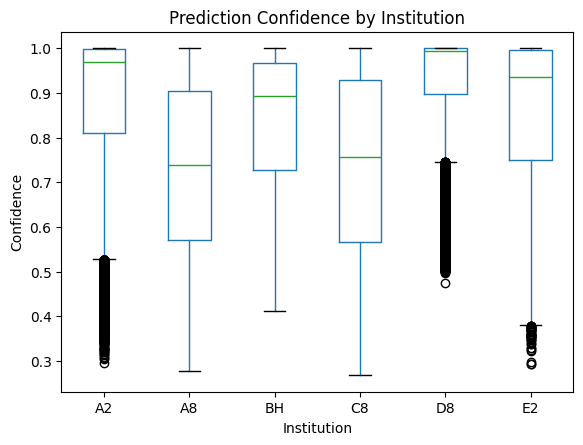

,site,Error Rate (%)
0,A2,47.665825
1,A8,66.711949
2,BH,19.175768
3,C8,62.876843
4,D8,27.409422
5,E2,43.801184


Correct,False,True
site,,
A2,25669,28183
A8,12277,6126
BH,1703,7178
C8,8572,5061
D8,3427,9076
E2,5402,6931


In [16]:
import pandas as pd

preds = pd.read_csv(
    "/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/test_predictions_with_probabilities.csv"
)

site_accuracy = (
    preds.groupby("site")["Correct"]
         .mean()
         .mul(100)
         .round(2)
         .sort_values(ascending=False)
         .reset_index(name="Accuracy (%)")
)

display(site_accuracy)
confidence = (
    preds.groupby("site")["Confidence"]
         .agg(["mean","std","median"])
         .round(3)
)

display(confidence)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

preds.boxplot(
    column="Confidence",
    by="site",
    grid=False
)

plt.suptitle("")
plt.title("Prediction Confidence by Institution")
plt.ylabel("Confidence")
plt.xlabel("Institution")

plt.show()
error = (
    preds.groupby("site")["Correct"]
         .apply(lambda x: 100*(~x).mean())
         .reset_index(name="Error Rate (%)")
)

display(error)
pd.crosstab(
    preds.site,
    preds.Correct
)

In [17]:
import pandas as pd

preds = pd.read_csv(
    "/kaggle/input/datasets/anishapanja/breast-cancer-resnet50-baseline-results/resnet50_outputs_v3/test_predictions_with_probabilities.csv"
)

for site in sorted(preds.site.unique()):
    print("\n" + "="*60)
    print(site)
    print("="*60)

    display(
        pd.crosstab(
            preds[preds.site == site]["true_subtype"],
            preds[preds.site == site]["predicted_subtype"]
        )
    )


A2


predicted_subtype,Basal,Her2,LumA,LumB
true_subtype,,,,
Basal,3914,118,1818,348
Her2,1155,251,2298,1276
LumA,2315,477,21924,2916
LumB,2547,215,10186,2094



A8


predicted_subtype,Basal,Her2,LumA,LumB
true_subtype,,,,
Basal,1537,1217,933,313
Her2,223,467,1975,983
LumA,201,338,2355,750
LumB,701,1186,3457,1767



BH


...

predicted_subtype,Basal,Her2,LumA,LumB
true_subtype,,,,
Her2,936,3561,1734,1402
LumA,119,1642,1340,899
LumB,24,803,1013,160



D8


predicted_subtype,Her2,LumB
true_subtype,,
LumB,3427,9076



E2


predicted_subtype,Basal,Her2,LumA,LumB
true_subtype,,,,
Basal,1880,103,1741,42
LumA,734,208,4881,745
LumB,697,29,1103,170


In [18]:
from scipy.stats import chi2_contingency
import pandas as pd

contingency = pd.crosstab(preds["site"], preds["Correct"])

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.10f}")

display(contingency)

Chi-square statistic: 8960.1806
Degrees of freedom: 5
P-value: 0.0000000000


Correct,False,True
site,,
A2,25669,28183
A8,12277,6126
BH,1703,7178
C8,8572,5061
D8,3427,9076
E2,5402,6931


<Figure size 600x500 with 0 Axes>

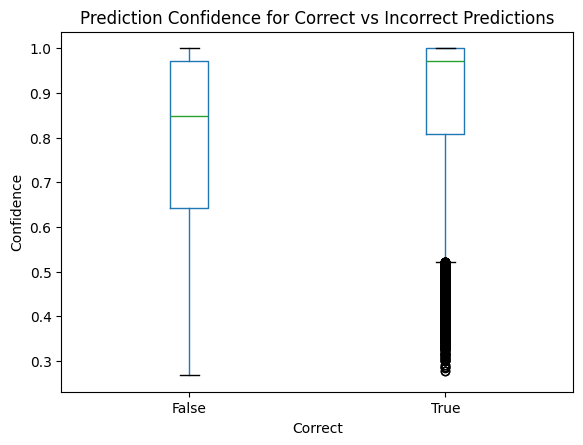

             mean       std    50%
Correct                           
False    0.796755  0.185764  0.847
True     0.882700  0.160315  0.970
U statistic: 2387201610.0
p-value: 0.0


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

preds.boxplot(
    column="Confidence",
    by="Correct",
    grid=False
)

plt.suptitle("")
plt.title("Prediction Confidence for Correct vs Incorrect Predictions")
plt.ylabel("Confidence")

plt.show()

print(
    preds.groupby("Correct")["Confidence"]
         .describe()[["mean","std","50%"]]
)
from scipy.stats import mannwhitneyu

correct = preds.loc[preds["Correct"], "Confidence"]
incorrect = preds.loc[~preds["Correct"], "Confidence"]

U, p = mannwhitneyu(
    correct,
    incorrect,
    alternative="two-sided"
)

print("U statistic:", U)
print("p-value:", p)